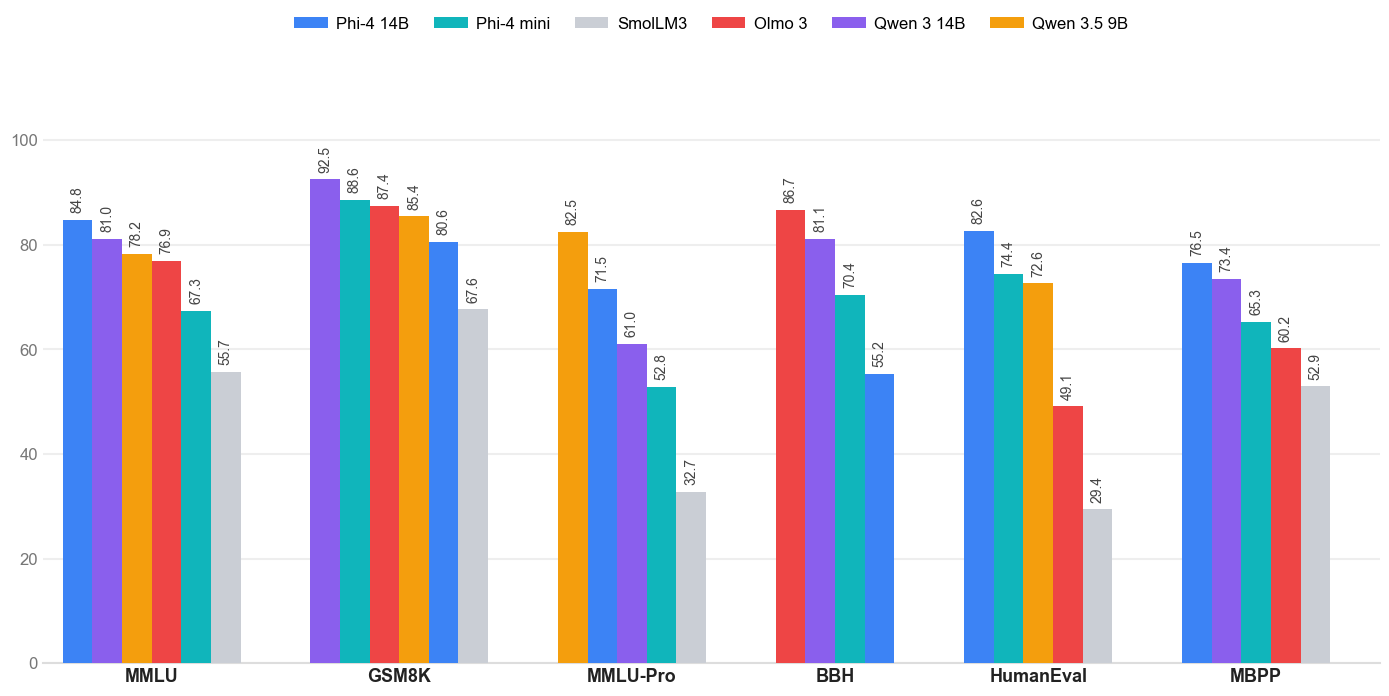

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Vos données
data = {
    'Modèle': ['Phi-4 14B', 'Phi-4 mini', 'SmolLM3', 'Olmo 3', 'Qwen 3 14B', 'Qwen 3.5 9B'],
    'MMLU': [84.8, 67.3, 55.7, 76.9, 81.05, 78.2],
    'GSM8K': [80.6, 88.6, 67.63, 87.4, 92.49, 85.4],
    'MMLU-Pro': [71.5, 52.8, 32.7, np.nan, 61.03, 82.5],
    'BBH': [55.24, 70.4, np.nan, 86.7, 81.07, np.nan],
    'HumanEval': [82.6, 74.4, 29.4, 49.1, np.nan, 72.6],
    'MBPP': [76.5, 65.3, 52.91, 60.2, 73.4, np.nan]
}
df = pd.DataFrame(data).set_index('Modèle')
df_t = df.T 

# 2. Configuration globale (Style épuré)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#ffffff",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

# 3. Les couleurs EXACTES extraites de votre dernière image
color_map = {
    'Phi-4 14B': '#3c83f5',    # Bleu vif
    'Phi-4 mini': '#10b5bb',   # Cyan / Vert d'eau
    'SmolLM3': '#caced5',      # Gris clair (idéal pour un plus petit modèle)
    'Olmo 3': '#ee4545',       # Rouge corail
    'Qwen 3 14B': '#8a5fed',   # Violet
    'Qwen 3.5 9B': '#f49e0d'   # Orange
}

# 4. Création de la figure
fig, ax = plt.subplots(figsize=(14, 7))

# 5. Algorithme de placement dynamique SANS TROUS
bar_width = 0.85
group_spacing = 2.0  # Espace entre les différents benchmarks
current_x = 0

ticks_x = []
ticks_labels = []
legend_patches = {} 

for bench in df_t.index:
    valid_models = df_t.loc[bench].dropna().sort_values(ascending=False)
    
    if len(valid_models) == 0:
        continue
        
    start_x = current_x
    
    for model_name, score in valid_models.items():
        color = color_map[model_name]
        
        # Dessin de la barre
        bar = ax.bar(current_x, score, width=bar_width, color=color, zorder=3)
        
        # Sauvegarde d'un patch pour la légende
        if model_name not in legend_patches:
            legend_patches[model_name] = bar
            
        # Annotation de la valeur au-dessus de la barre
        ax.annotate(f'{score:.1f}',
                    (current_x, score),
                    ha='center', va='bottom',
                    fontsize=10,
                    color='#444444',
                    xytext=(0, 5),
                    textcoords='offset points',
                    rotation=90)
        
        current_x += bar_width
    
    # Calcul du centre du groupe pour l'axe X
    end_x = current_x - bar_width
    group_center = (start_x + end_x) / 2
    ticks_x.append(group_center)
    ticks_labels.append(bench)
    
    current_x += group_spacing

# 6. Nettoyage de l'interface
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#DDDDDD')
ax.spines['bottom'].set_linewidth(1.5)

ax.grid(axis='y', color='#EEEEEE', linestyle='-', linewidth=1.5, zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', which='both', length=0)
plt.yticks(fontsize=12, color='#777777')
plt.xticks(ticks_x, ticks_labels, fontsize=13, color='#222222', fontweight='bold')

# 7. Création de la légende
ordered_handles = [legend_patches[m] for m in df.index if m in legend_patches]
ax.legend(ordered_handles, df.index, loc='upper center', bbox_to_anchor=(0.5, 1.1),
          ncol=6, frameon=False, fontsize=12, handletextpad=0.5, 
          columnspacing=1.5)

# Marges
ax.set_ylim(0, 115)
ax.set_xlim(-1, current_x - group_spacing + 1)

plt.tight_layout()
plt.show()

# plt.savefig('final_benchmarks_custom_colors.pdf')